<a href="https://colab.research.google.com/github/tmedeirosb/tsi-ad-2025/blob/main/MODULO_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# exibir todas as colunas
pd.set_option('display.max_columns', None)

url = "https://raw.githubusercontent.com/tmedeirosb/tsi-ad-2025/refs/heads/main/dados/dados_workflow_ivan.csv"
df = pd.read_csv(url)

display(df.head())

display(df.info())

,LnguaPortuguesaeLiteraturaI90H,LnguaPortuguesaeLiteraturaI90H_dependencia,LnguaPortuguesaeLiteraturaI90H_freq,MatemticaI120H,MatemticaI120H_dependencia,MatemticaI120H_freq,aluno_exclusivo_rede_publica,descricao,descricao_area_residencial,descricao_companhia_domiciliar,descricao_estado_civil,descricao_historico,descricao_imovel,descricao_mae_escolaridade,descricao_pai_escolaridade,descricao_raca,descricao_responsavel_escolaridade,descricao_responsavel_financeiro,descricao_trabalho,id,idade,pessoa_fisica__sexo,possui_necessidade_especial,qnt_pc,qtd_pessoas_domicilio,sigla,tempo_entre_conclusao_ingresso,qnt_salarios,artificial,classe,conceito,conceito_freq,acompanhamento
0,68.0,0,100.0,66.0,0,100.0,False,Matriculado,Urbana,Mãe,Solteiro(a),Técnico de Nivel Médio em Informática,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Branca,Ensino fundamental incompleto,Mãe,Não informado,457884597605,15,F,False,0,2,LAJ,1,1,0,1,B,A,0
1,73.0,1,100.0,36.0,1,91.0,False,Cancelado,Urbana,Mãe,Solteiro(a),Técnico de Nível Médio em Meio Ambiente,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Parda,Ensino fundamental incompleto,Mãe,Não informado,458436647741,17,M,False,1,2,SPP,2,1,1,0,R,R,0
2,61.0,0,100.0,60.0,0,100.0,False,Matriculado,Urbana,Pais,Solteiro(a),Técnico de Nivel Médio em Informática,Alugado,Ensino médio completo,Ensino médio completo,Parda,Ensino médio completo,Mãe,Não informado,464029640533,15,M,True,0,5,CANG,2,2,0,1,B,A,0
3,NaN,-1,NaN,NaN,-1,NaN,False,Matriculado,Urbana,Pais,Solteiro(a),Técnico de Nível Médio em Mecânica,Alugado,Alfabetizado,Não estudou,Parda,Ensino fundamental incompleto,Mãe,Não está trabalhando,556372572373,16,F,False,1,5,MO,3,2,0,1,S,S,0
4,69.0,0,100.0,63.0,0,100.0,False,Matriculado,Urbana,Mãe,Solteiro(a),Técnico de Nivel Médio Informática,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Preta,Ensino fundamental incompleto,Mãe,Não está trabalhando,457614148801,15,F,False,0,3,PAR,1,1,0,1,R,A,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8908 entries, 0 to 8907
Data columns (total 33 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   LnguaPortuguesaeLiteraturaI90H              7218 non-null   float64
 1   LnguaPortuguesaeLiteraturaI90H_dependencia  8908 non-null   int64  
 2   LnguaPortuguesaeLiteraturaI90H_freq         7215 non-null   float64
 3   MatemticaI120H                              7213 non-null   float64
 4   MatemticaI120H_dependencia                  8908 non-null   int64  
 5   MatemticaI120H_freq                         7210 non-null   float64
 6   aluno_exclusivo_rede_publica                8908 non-null   bool   
 7   descricao                                   8908 non-null   object 
 8   descricao_area_residencial                  8908 non-null   object 
 9   descricao_companhia_domiciliar              8908 non-null   object 
 10  descricao_es

None

## Tratamento de Dados Ausentes



In [ ]:
print("Valores ausentes por coluna:\n", df.isnull().sum()[df.isnull().sum() > 0])

Valores ausentes por coluna:
 LnguaPortuguesaeLiteraturaI90H         1690
LnguaPortuguesaeLiteraturaI90H_freq    1693
MatemticaI120H                         1695
MatemticaI120H_freq                    1698
dtype: int64


Visualização de dados ausentes usando missingno:


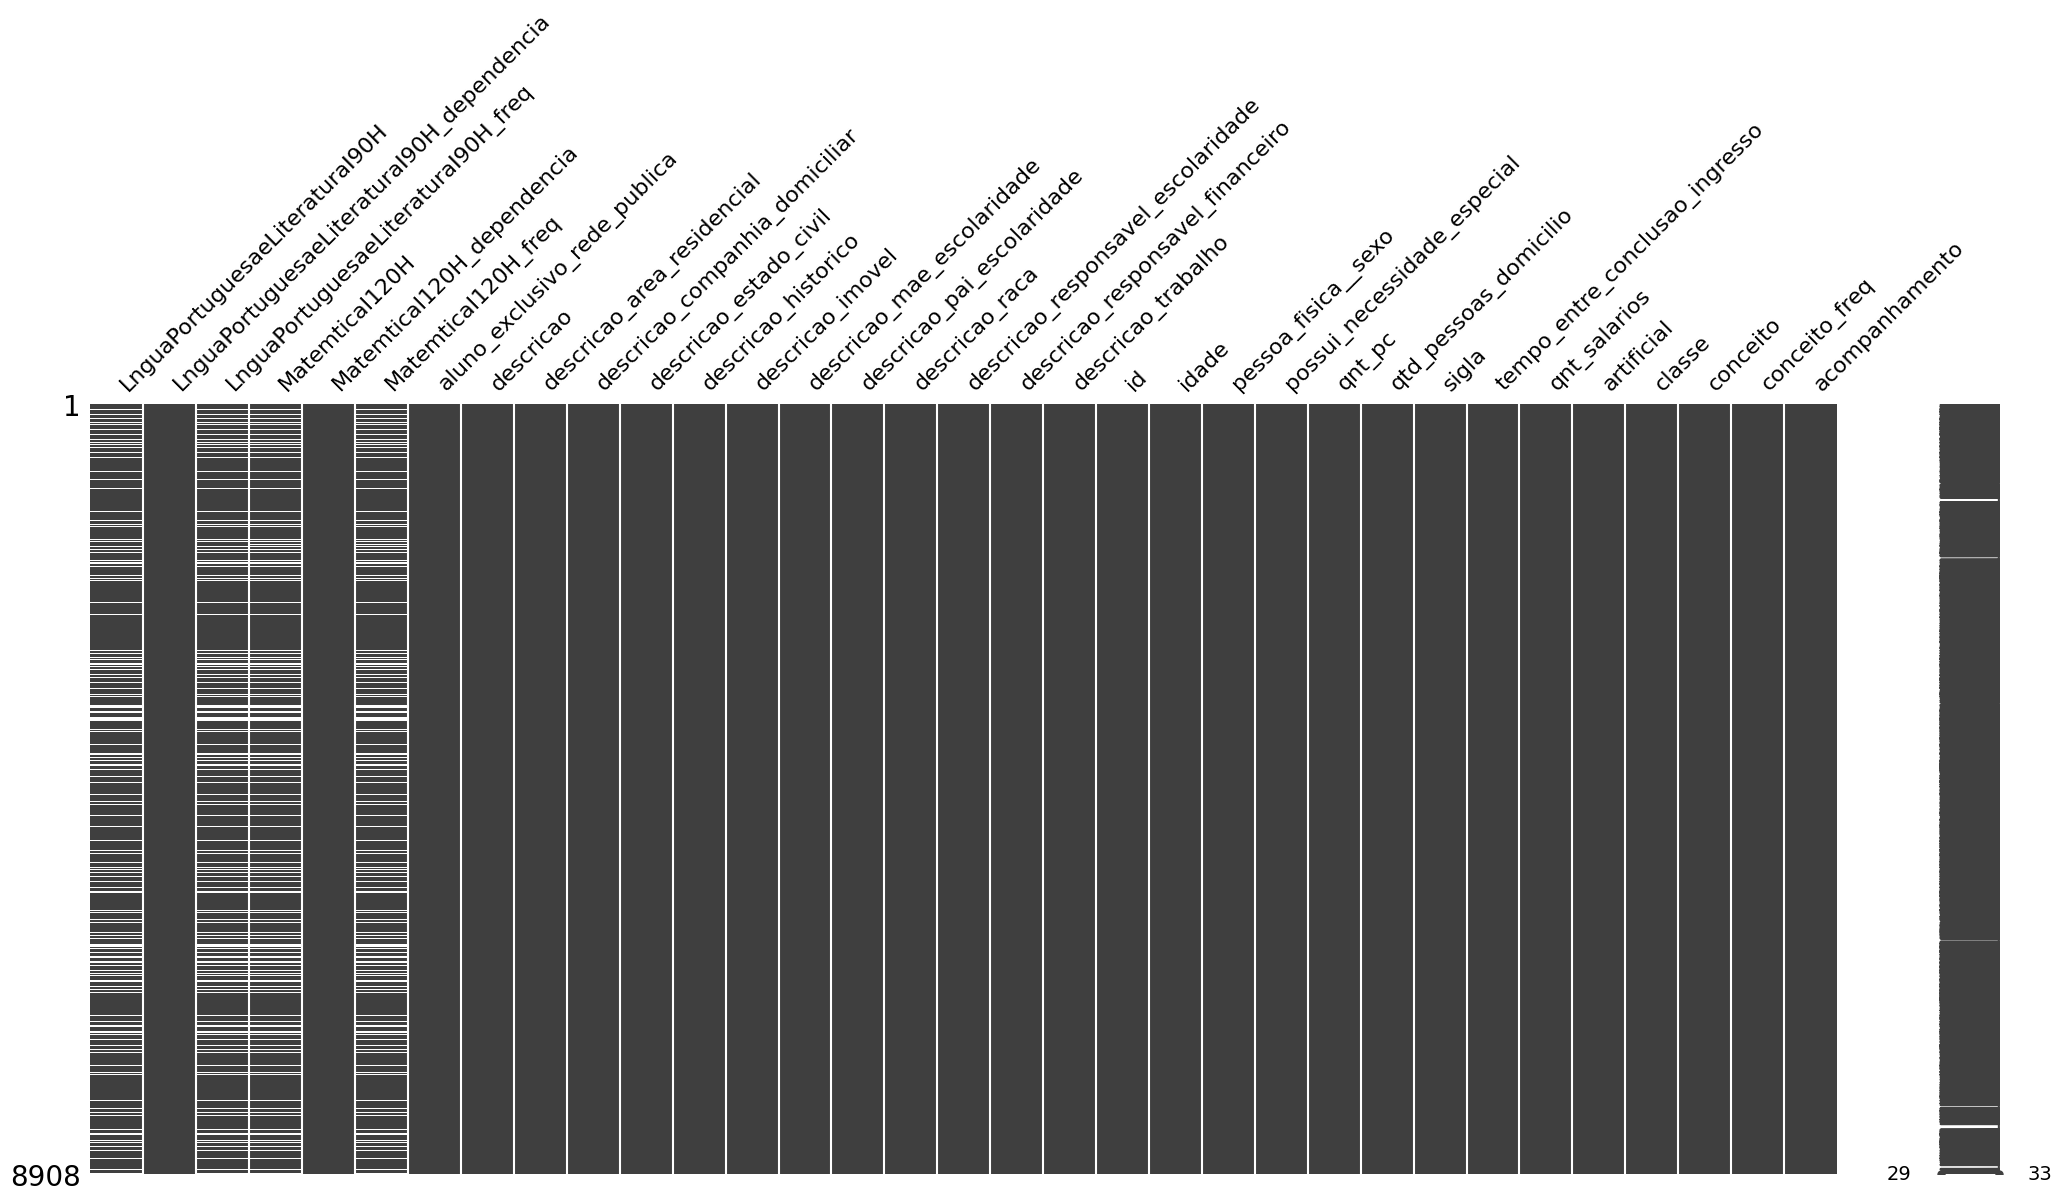

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt

print("Visualização de dados ausentes usando missingno:")
msno.matrix(df)
plt.show()

In [ ]:
for col in ['LnguaPortuguesaeLiteraturaI90H', 'LnguaPortuguesaeLiteraturaI90H_freq', 'MatemticaI120H', 'MatemticaI120H_freq']:
    if df[col].isnull().any():
        mean_value = df[col].mean()
        df[col] = df[col].fillna(mean_value)

print("Valores ausentes após preenchimento:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Valores ausentes após preenchimento:
Series([], dtype: int64)


### Dados Ausentes e sua Importância

Dados ausentes são valores não registrados ou indisponíveis em um conjunto de dados. Eles podem surgir por diversas razões, como erros na coleta, falha de equipamentos, ou informações não fornecidas pelos entrevistados. Ignorar dados ausentes ou tratá-los de forma inadequada pode levar a análises tendenciosas, modelos imprecisos e conclusões errôneas.

**Importância do Tratamento:**

*   **Integridade da Análise:** Garante que as estatísticas e os resultados dos modelos sejam baseados em dados completos e representativos.
*   **Desempenho do Modelo:** Muitos algoritmos de Machine Learning não conseguem lidar diretamente com valores ausentes e podem falhar ou produzir resultados subótimos.
*   **Redução de Viés:** Um tratamento adequado pode ajudar a mitigar vieses que poderiam ser introduzidos se os dados ausentes não fossem distribuídos aleatoriamente.

**Métodos de Tratamento Utilizados:**

Neste exemplo, utilizamos o método de **imputação pela média** para colunas numéricas. A média é uma medida de tendência central que substitui os valores ausentes pelo valor médio observado na coluna. Este é um método simples e eficaz para variáveis numéricas quando a ausência dos dados é considerada aleatória e a distribuição da variável não é extremamente assimétrica.

Outros métodos comuns incluem:

*   **Imputação pela Mediana:** Similar à média, mas menos sensível a outliers.
*   **Imputação pela Moda:** Usada para variáveis categóricas, substituindo valores ausentes pelo valor mais frequente.
*   **Remoção de Linhas/Colunas:** Em casos onde a quantidade de dados ausentes é muito pequena ou muito grande, respectivamente, e não prejudica a análise.
*   **Imputação por Modelos Preditivos:** Utiliza outros atributos para prever os valores ausentes.

## Substituição de Valores



In [ ]:
print("Valores únicos antes da substituição na coluna 'pessoa_fisica__sexo':")
print(df['pessoa_fisica__sexo'].value_counts())

Valores únicos antes da substituição na coluna 'pessoa_fisica__sexo':
pessoa_fisica__sexo
F    4554
M    4354
Name: count, dtype: int64


In [ ]:
df['pessoa_fisica__sexo'] = df['pessoa_fisica__sexo'].replace({'F': 'Mulher', 'M': 'Homem'})

print("Valores únicos após a substituição na coluna 'pessoa_fisica__sexo':")
print(df['pessoa_fisica__sexo'].value_counts())

Valores únicos após a substituição na coluna 'pessoa_fisica__sexo':
pessoa_fisica__sexo
Mulher    4554
Homem     4354
Name: count, dtype: int64


### Explicação sobre Substituição de Valores

A substituição de valores é uma técnica essencial no pré-processamento de dados que permite corrigir inconsistências, padronizar entradas e tornar os dados mais utilizáveis para análise e modelagem. Dados podem vir de diversas fontes com diferentes convenções de nomenclatura, erros de digitação, ou variações na representação de uma mesma categoria.

**Importância da Substituição de Valores:**

*   **Correção de Inconsistências:** Garante que categorias que significam a mesma coisa (ex: 'F', 'Feminino', 'Mulher') sejam representadas de forma uniforme, evitando que sejam tratadas como categorias distintas.
*   **Padronização de Dados:** Cria um vocabulário comum para as variáveis, o que facilita a compreensão, a análise e a aplicação de algoritmos de Machine Learning.
*   **Melhora da Qualidade dos Dados:** Reduz a "sujeira" nos dados, tornando o conjunto de dados mais limpo e confiável.
*   **Prevenção de Erros na Análise:** Dados não padronizados podem levar a erros em contagens, agrupamentos ou outras operações analíticas.

Neste exemplo, padronizamos os valores da coluna 'pessoa_fisica__sexo' de 'F' e 'M' para 'Mulher' e 'Homem', respectivamente. Esta é uma prática comum para melhorar a legibilidade e a interpretabilidade dos dados, especialmente em relatórios ou ao integrar com outros sistemas que esperam esses formatos específicos.

## Remoção de Dados Duplicados



In [ ]:
print("Número de linhas duplicadas antes da remoção:", df.duplicated().sum())

Número de linhas duplicadas antes da remoção: 0


In [ ]:
df = df.drop_duplicates()
print("Número de linhas duplicadas após a remoção:", df.duplicated().sum())

Número de linhas duplicadas após a remoção: 0


### Explicação sobre Dados Duplicados

Dados duplicados são registros idênticos ou muito semelhantes que aparecem mais de uma vez em um conjunto de dados. Eles podem surgir por diversos motivos, como erros na entrada de dados, fusão de diferentes fontes de dados, ou falhas em processos de coleta.

**Impactos na Análise de Dados:**

*   **Resultados Enviesados:** Duplicatas podem superestimar a frequência de certas observações, levando a estatísticas descritivas incorretas (como média, mediana, contagens) e análises inferenciais enganosas.
*   **Modelos Imprecisos:** Em Machine Learning, dados duplicados podem fazer com que um modelo seja treinado excessivamente em determinadas instâncias, resultando em overfitting e desempenho ruim em novos dados.
*   **Ineficiência Computacional:** Processar um volume maior de dados do que o necessário consome mais recursos computacionais e tempo, especialmente em grandes conjuntos de dados.
*   **Análise de Relacionamento Distorcida:** Relações entre variáveis podem parecer mais fortes ou mais fracas do que realmente são, devido à influência de registros repetidos.

**Como a Técnica foi Aplicada:**

Neste exemplo, utilizamos o método `.drop_duplicates()` do pandas para identificar e remover quaisquer linhas que fossem completamente idênticas em todas as colunas do DataFrame `df`. Embora a verificação inicial tenha mostrado que não havia duplicatas no DataFrame carregado, a aplicação desta função garante que, caso duplicatas surjam em futuras operações ou se o conjunto de dados for atualizado, elas serão tratadas de forma eficaz. Esta é uma etapa crucial no pré-processamento para manter a integridade e a qualidade dos dados.

## Discretização (Binning)

### Explicação sobre Discretização (Binning)

Discretização, também conhecida como binning, é o processo de transformar variáveis numéricas contínuas em variáveis categóricas ou ordinais. Em vez de usar os valores numéricos exatos, a discretização agrupa esses valores em intervalos ou "bins" (faixas), atribuindo a cada observação a categoria correspondente ao intervalo em que seu valor cai.

**Utilidade e Importância:**

*   **Redução de Ruído:** Variáveis contínuas podem conter muito ruído ou detalhes irrelevantes que podem ser suavizados ao agrupá-los em faixas. Isso pode levar a modelos mais robustos.
*   **Melhora a Interpretabilidade:** É mais fácil interpretar e comunicar insights quando os dados estão em categorias significativas (ex: "jovem", "adulto") do que em valores numéricos exatos.
*   **Lidar com Outliers:** Valores extremos (outliers) podem ter um impacto desproporcional em análises e modelos. A discretização pode mitigar esse efeito, agrupando-os em faixas com outros valores.
*   **Pré-requisito para Alguns Algoritmos:** Alguns algoritmos de Machine Learning (como árvores de decisão) podem se beneficiar ou até exigir variáveis categóricas. Discretizar variáveis numéricas pode melhorar o desempenho desses modelos.
*   **Redução da Complexidade:** Diminui a quantidade de valores únicos, o que pode simplificar o modelo e reduzir a dimensionalidade em certos contextos.

**Quando Aplicar:**

É aplicada quando a relação entre uma variável numérica e a variável alvo não é linear, quando se deseja focar em padrões de grupos em vez de valores individuais, para facilitar a interpretação dos resultados, ou quando a natureza dos dados sugere agrupamentos lógicos (como faixas etárias, categorias de renda, etc.).

In [ ]:
print("Distribuição de valores da coluna 'idade' antes da discretização:\n", df['idade'].value_counts().sort_index())

Distribuição de valores da coluna 'idade' antes da discretização:
 idade
0        3
12       1
13     224
14    3160
15    3957
16    1162
17     279
18      57
19      22
20      12
21       5
22       4
23       4
24       3
25       3
26       3
27       1
29       1
30       1
33       2
34       1
37       1
45       1
57       1
Name: count, dtype: int64


In [ ]:
bins = [0, 25, 35, 50, df['idade'].max() + 1]
labels = ['Jovem', 'Adulto Jovem', 'Adulto', 'Idoso']
df['faixa_etaria'] = pd.cut(df['idade'], bins=bins, labels=labels, right=False)

print("Contagem de valores da nova coluna 'faixa_etaria':")
print(df['faixa_etaria'].value_counts())

Contagem de valores da nova coluna 'faixa_etaria':
faixa_etaria
Jovem           8893
Adulto Jovem      12
Adulto             2
Idoso              1
Name: count, dtype: int64


## Criação de Matriz Dummy



### Explicação sobre Criação de Variáveis Dummy (One-Hot Encoding)

A criação de variáveis dummy, também conhecida como One-Hot Encoding, é uma técnica fundamental de pré-processamento de dados utilizada para transformar variáveis categóricas em um formato numérico que pode ser compreendido e processado por algoritmos de Machine Learning. Muitos algoritmos de aprendizado de máquina não conseguem trabalhar diretamente com dados categóricos (textuais) e esperam entradas numéricas.

**O que é One-Hot Encoding?**

Para cada categoria única em uma coluna, o One-Hot Encoding cria uma nova coluna binária (dummy). Se uma observação pertence a essa categoria, o valor na nova coluna é 1; caso contrário, é 0. Por exemplo, se tivermos uma coluna 'Cor' com os valores 'Vermelho', 'Azul', 'Verde', ela será transformada em três novas colunas: 'Cor_Vermelho', 'Cor_Azul', 'Cor_Verde'. Uma linha que originalmente tinha 'Vermelho' na coluna 'Cor' terá 1 na 'Cor_Vermelho' e 0 nas outras duas.

**Importância para Algoritmos de Machine Learning:**

1.  **Compatibilidade com Algoritmos:** A maioria dos algoritmos de ML é baseada em matemática e estatística, que operam com números. A conversão de categorias em um formato numérico é essencial para que esses algoritmos possam utilizá-las.
2.  **Evitar a Imposição de Ordem:** Se uma variável categórica com mais de duas classes fosse codificada diretamente com números (ex: 1, 2, 3), o algoritmo poderia inferir uma ordem (1 < 2 < 3) que não existe na realidade. O One-Hot Encoding evita essa suposição, tratando cada categoria como igualmente distante das outras.
3.  **Melhora do Desempenho do Modelo:** Ao representar as categorias de forma independente, os modelos podem aprender relações mais complexas entre as diferentes categorias e a variável alvo, o que pode levar a um melhor desempenho preditivo.
4.  **Representação Discreta:** Ajuda o modelo a entender que as categorias são entidades separadas e discretas, sem qualquer relacionamento ordinal inerente.

Neste exemplo, aplicaremos `pd.get_dummies` para transformar uma coluna categórica em várias colunas dummy, tornando-a pronta para uso em modelos de Machine Learning.

In [ ]:
print("Valores únicos e suas contagens na coluna 'descricao_raca' antes da transformação:\n", df['descricao_raca'].value_counts())

Valores únicos e suas contagens na coluna 'descricao_raca' antes da transformação:
 descricao_raca
Parda            5103
Branca           2786
Preta             779
Amarela           126
Não declarado      78
Indígena           36
Name: count, dtype: int64


In [ ]:
# Identificar todas as colunas categóricas (object e category)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Colunas categóricas a serem transformadas em variáveis dummy:\n", categorical_cols)

# Criar variáveis dummy para todas as colunas categóricas, usando drop_first=True para evitar multicolinearidade
df_dummies_all = pd.get_dummies(df[categorical_cols], prefix=categorical_cols, drop_first=True)

# Concatenar as novas colunas dummy ao DataFrame original
df = pd.concat([df, df_dummies_all], axis=1)

# Remover as colunas categóricas originais do DataFrame
df = df.drop(columns=categorical_cols)

print("\nPrimeiras linhas do DataFrame com as novas colunas dummy (e colunas categóricas originais removidas):")
display(df.head())

print("\nVerificação dos tipos de dados após a criação das dummies e remoção das colunas originais:")
print(df.info())

Colunas categóricas a serem transformadas em variáveis dummy:
 ['descricao', 'descricao_area_residencial', 'descricao_companhia_domiciliar', 'descricao_estado_civil', 'descricao_historico', 'descricao_imovel', 'descricao_mae_escolaridade', 'descricao_pai_escolaridade', 'descricao_raca', 'descricao_responsavel_escolaridade', 'descricao_responsavel_financeiro', 'descricao_trabalho', 'pessoa_fisica__sexo', 'sigla', 'conceito', 'conceito_freq', 'faixa_etaria']

Primeiras linhas do DataFrame com as novas colunas dummy (e colunas categóricas originais removidas):


,LnguaPortuguesaeLiteraturaI90H,LnguaPortuguesaeLiteraturaI90H_dependencia,LnguaPortuguesaeLiteraturaI90H_freq,MatemticaI120H,MatemticaI120H_dependencia,MatemticaI120H_freq,aluno_exclusivo_rede_publica,id,idade,possui_necessidade_especial,qnt_pc,qtd_pessoas_domicilio,tempo_entre_conclusao_ingresso,qnt_salarios,artificial,classe,acompanhamento,descricao_Cancelamento Compulsório,descricao_Concluído,descricao_Evasão,descricao_Matriculado,descricao_area_residencial_Comunidade Quilombola,descricao_area_residencial_Não informado,descricao_area_residencial_Rural,descricao_area_residencial_Urbana,descricao_companhia_domiciliar_Mãe,descricao_companhia_domiciliar_Não informado,descricao_companhia_domiciliar_Outros,descricao_companhia_domiciliar_Pai,descricao_companhia_domiciliar_Pais,descricao_companhia_domiciliar_Parente(s) ou amigo(s),descricao_companhia_domiciliar_Sozinho(a),descricao_estado_civil_Divorciado(a),descricao_estado_civil_Não declarado,descricao_estado_civil_Solteiro(a),descricao_estado_civil_União Estável,"descricao_historico_Técnico de Nivel Médio em Agropecuária, na Forma Integrada",descricao_historico_Técnico de Nivel Médio em Biocombustíveis,descricao_historico_Técnico de Nivel Médio em Equipamentos Biomédicos,descricao_historico_Técnico de Nivel Médio em Informática,descricao_historico_Técnico de Nível Médio em Administração,descricao_historico_Técnico de Nível Médio em Agroecologia,descricao_historico_Técnico de Nível Médio em Alimentos,descricao_historico_Técnico de Nível Médio em Apicultura,descricao_historico_Técnico de Nível Médio em Comércio,descricao_historico_Técnico de Nível Médio em Controle Ambiental,descricao_historico_Técnico de Nível Médio em Edificações,descricao_historico_Técnico de Nível Médio em Eletromecânica,descricao_historico_Técnico de Nível Médio em Eletrotécnica,descricao_historico_Técnico de Nível Médio em Eletrônica,descricao_historico_Técnico de Nível Médio em Eventos,descricao_historico_Técnico de Nível Médio em Geologia,descricao_historico_Técnico de Nível Médio em Informática,descricao_historico_Técnico de Nível Médio em Informática para Internet,descricao_historico_Técnico de Nível Médio em Lazer,descricao_historico_Técnico de Nível Médio em Logística,descricao_historico_Técnico de Nível Médio em Manutenção e Suporte em Informática,descricao_historico_Técnico de Nível Médio em Mecatrônica,descricao_historico_Técnico de Nível Médio em Mecânica,descricao_historico_Técnico de Nível Médio em Meio Ambiente,descricao_historico_Técnico de Nível Médio em Mineração,descricao_historico_Técnico de Nível Médio em Multimídia,descricao_historico_Técnico de Nível Médio em Química,"descricao_historico_Técnico de Nível Médio em Química, na Forma Integrado",descricao_historico_Técnico de Nível Médio em Recursos Pesqueiros,descricao_historico_Técnico de Nível Médio em Refrigeração e Climatização,descricao_historico_Técnico de Nível Médio em Têxtil,descricao_historico_Técnico de Nível Médio em Vestuário,descricao_historico_Técnico em Programação de Jogos Digitais,descricao_imovel_Cedido ou Emprestado,descricao_imovel_Financiado,descricao_imovel_Não informado,descricao_imovel_Outro,descricao_imovel_Pensionato ou Alojamento,descricao_imovel_Próprio,descricao_mae_escolaridade_Ensino fundamental completo,descricao_mae_escolaridade_Ensino fundamental incompleto,descricao_mae_escolaridade_Ensino médio completo,descricao_mae_escolaridade_Ensino médio incompleto,descricao_mae_escolaridade_Ensino superior completo,descricao_mae_escolaridade_Ensino superior incompleto,descricao_mae_escolaridade_Não conhece,descricao_mae_escolaridade_Não estudou,descricao_mae_escolaridade_Pós graduação completo,descricao_mae_escolaridade_Pós graduação incompleto,descricao_pai_escolaridade_Ensino fundamental completo,descricao_pai_escolaridade_Ensino fundamental incompleto,descricao_pai_escolaridade_Ensino médio completo,descricao_pai_escolaridade_Ensino médio incompleto,descricao_pai_escolaridade_Ensino superior completo,descricao_


Verificação dos tipos de dados após a criação das dummies e remoção das colunas originais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8908 entries, 0 to 8907
Columns: 160 entries, LnguaPortuguesaeLiteraturaI90H to faixa_etaria_Idoso
dtypes: bool(145), float64(4), int64(11)
memory usage: 2.3 MB
None


## Escalonamento de Variáveis


### Explicação sobre Escalonamento de Variáveis Numéricas

Escalonamento de variáveis é uma etapa crucial no pré-processamento de dados que visa ajustar a escala de variáveis numéricas para um intervalo padrão. Isso é particularmente importante para algoritmos de Machine Learning que são sensíveis à magnitude e à unidade das features.

**Por que o Escalonamento é Importante?**

Algoritmos baseados em distância, como K-Nearest Neighbors (KNN), Support Vector Machines (SVMs) e K-Means, são fortemente influenciados pela magnitude das features. Se uma feature tem um intervalo de valores muito maior que outra, ela pode dominar a função de distância e, consequentemente, o modelo, independentemente de sua real importância para o problema. Por exemplo, se a coluna 'renda' varia de 0 a 1.000.000 e a coluna 'idade' varia de 0 a 100, a 'renda' terá um peso desproporcionalmente maior na maioria das métricas de distância. O escalonamento garante que todas as features contribuam igualmente para a medida de distância.

Além disso, algoritmos baseados em gradiente, como Regressão Logística e Redes Neurais, convergem mais rapidamente e de forma mais estável quando as features estão em uma escala similar. A ausência de escalonamento pode levar a problemas de otimização, como oscilações ou lentidão na convergência.

**Técnicas Comuns de Escalonamento:**

Duas das técnicas mais comuns são:

1.  **MinMaxScaler (Normalização):** Esta técnica escala os dados para um intervalo fixo, geralmente entre 0 e 1 (ou -1 e 1). Ele realiza a seguinte transformação:
    `X_scaled = (X - X_min) / (X_max - X_min)`
    *   **Vantagens:** Garante que todos os valores fiquem dentro de um intervalo específico, o que é útil para algoritmos que esperam entradas de pequena escala (como redes neurais). Não afeta a forma da distribuição dos dados.
    *   **Desvantagens:** É sensível a outliers, pois valores mínimos e máximos extremos podem distorcer o intervalo e comprimir a maioria dos dados em uma faixa muito pequena.

2.  **StandardScaler (Padronização):** Esta técnica transforma os dados para ter média 0 e desvio padrão 1. É baseada na estatística Z-score:
    `X_scaled = (X - média) / desvio_padrão`
    *   **Vantagens:** Não é tão sensível a outliers quanto o MinMaxScaler, pois a transformação é baseada na média e no desvio padrão, que são mais robustos a valores extremos do que os valores mínimos e máximos. Preserva informações sobre outliers.
    *   **Desvantagens:** Não garante um intervalo de saída específico para os dados. Os valores podem ser negativos.

A escolha entre MinMaxScaler e StandardScaler depende do algoritmo a ser utilizado e da distribuição dos dados. Para este exemplo, usaremos o StandardScaler para demonstrar a padronização dos dados.

In [ ]:
from sklearn.preprocessing import MinMaxScaler # Usando MinMaxScaler

# Instantiate MinMaxScaler
scaler = MinMaxScaler() # Usando MinMaxScaler

# Lista das colunas 'nota' e 'freq' que precisam ser escalonadas
columns_to_scale = [
    'LnguaPortuguesaeLiteraturaI90H',
    'LnguaPortuguesaeLiteraturaI90H_freq',
    'MatemticaI120H',
    'MatemticaI120H_freq'
]

# Aplicar o escalonamento a cada uma dessas colunas e criar novas colunas escalonadas
for col in columns_to_scale:
    # Verifica se a coluna ainda existe no DataFrame antes de tentar escalonar
    if col in df.columns:
        df[f'{col}_scaled'] = scaler.fit_transform(df[[col]])
        print(f"Coluna '{col}' escalonada com sucesso usando MinMaxScaler e armazenada em '{col}_scaled'.")
    else:
        print(f"Aviso: Coluna '{col}' não encontrada no DataFrame, pulando escalonamento.")

Coluna 'LnguaPortuguesaeLiteraturaI90H' escalonada com sucesso usando MinMaxScaler e armazenada em 'LnguaPortuguesaeLiteraturaI90H_scaled'.
Coluna 'LnguaPortuguesaeLiteraturaI90H_freq' escalonada com sucesso usando MinMaxScaler e armazenada em 'LnguaPortuguesaeLiteraturaI90H_freq_scaled'.
Coluna 'MatemticaI120H' escalonada com sucesso usando MinMaxScaler e armazenada em 'MatemticaI120H_scaled'.
Coluna 'MatemticaI120H_freq' escalonada com sucesso usando MinMaxScaler e armazenada em 'MatemticaI120H_freq_scaled'.


In [ ]:
print("Estatísticas descritivas das colunas escalonadas (amostra):")
print(df[['LnguaPortuguesaeLiteraturaI90H_scaled', 'LnguaPortuguesaeLiteraturaI90H_freq_scaled', 'MatemticaI120H_freq_scaled', 'MatemticaI120H_scaled']].describe())

Estatísticas descritivas das colunas escalonadas (amostra):
       LnguaPortuguesaeLiteraturaI90H_scaled  \
count                            8908.000000   
mean                                0.692472   
std                                 0.172070   
min                                 0.000000   
25%                                 0.650000   
50%                                 0.692472   
75%                                 0.790000   
max                                 1.000000   

       LnguaPortuguesaeLiteraturaI90H_freq_scaled  MatemticaI120H_freq_scaled  \
count                                 8908.000000                 8908.000000   
mean                                     0.956147                    0.955657   
std                                      0.083863                    0.082625   
min                                      0.000000                    0.000000   
25%                                      0.956147                    0.955657   
50%                  

## Transformação de Distribuição


### Explicação sobre Transformação de Distribuição

A transformação de distribuição é uma técnica de pré-processamento de dados utilizada para ajustar a forma da distribuição de uma variável numérica. O objetivo principal é torná-la mais simétrica e, idealmente, mais próxima de uma distribuição normal (gaussiana). Muitos algoritmos de Machine Learning assumem que as variáveis de entrada seguem uma distribuição normal ou que possuem uma relação linear com a variável alvo. Quando esses pressupostos não são atendidos, o desempenho do modelo pode ser prejudicado.

**Importância para Modelos de Machine Learning:**

1.  **Melhora o Desempenho do Modelo:** Algoritmos baseados em distância (como KNN, K-Means), modelos lineares (Regressão Linear, Regressão Logística) e até mesmo Redes Neurais podem ter seu desempenho otimizado quando os dados de entrada seguem uma distribuição mais normalizada. A normalidade pode ajudar na convergência de algoritmos de otimização e na interpretabilidade dos pesos do modelo.
2.  **Redução da Influência de Outliers:** Variáveis assimétricas frequentemente possuem outliers na cauda mais longa. Transformações de distribuição podem mitigar o impacto desses outliers, "puxando" os valores extremos para mais perto da média.
3.  **Atendimento a Pressupostos Estatísticos:** Muitos testes estatísticos e modelos inferenciais dependem da suposição de normalidade dos dados.

**Transformação Logarítmica (Ex: `np.log1p`):**

A transformação logarítmica é uma das transformações mais comuns e eficazes para variáveis com distribuições assimétricas positivas ( skewed to the right ), onde a maioria dos valores se concentra na parte inferior do intervalo e há uma longa cauda à direita. Ela é particularmente útil para variáveis que representam contagens, rendas, tamanhos de população, etc., que tendem a ter uma distribuição exponencial ou log-normal.

A função `np.log1p(x)` (log(1+x)) é preferível à `np.log(x)` quando a variável pode conter valores zero. `np.log(0)` é indefinido (-infinito), enquanto `np.log1p(0)` é 0, o que evita erros e permite que valores zero sejam tratados adequadamente na transformação. Essa transformação "comprime" os valores maiores e "expande" os valores menores, reduzindo a assimetria e a variabilidade.

Ao aplicar a transformação logarítmica, esperamos que a distribuição da variável se torne mais simétrica e parecida com uma curva de sino, o que pode beneficiar a performance de vários modelos de Machine Learning.

In [ ]:
print("Estatísticas descritivas da coluna 'qnt_salarios' antes da transformação:\n", df['qnt_salarios'].describe())
print("Assimetria da coluna 'qnt_salarios' antes da transformação:\n", df['qnt_salarios'].skew())

Estatísticas descritivas da coluna 'qnt_salarios' antes da transformação:
 count    8908.000000
mean        2.196116
std         1.673883
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: qnt_salarios, dtype: float64
Assimetria da coluna 'qnt_salarios' antes da transformação:
 1.9384023869695022


In [ ]:
import numpy as np

df['qnt_salarios_log_transformed'] = np.log1p(df['qnt_salarios'])

print("Coluna 'qnt_salarios' transformada logaritmicamente e armazenada em 'qnt_salarios_log_transformed'.")

Coluna 'qnt_salarios' transformada logaritmicamente e armazenada em 'qnt_salarios_log_transformed'.


In [ ]:
print("Estatísticas descritivas da coluna 'qnt_salarios_log_transformed' após a transformação:")
print(df['qnt_salarios_log_transformed'].describe())
print("Assimetria da coluna 'qnt_salarios_log_transformed' após a transformação:")
print(df['qnt_salarios_log_transformed'].skew())

Estatísticas descritivas da coluna 'qnt_salarios_log_transformed' após a transformação:
count    8908.000000
mean        1.060500
std         0.422341
min         0.693147
25%         0.693147
50%         1.098612
75%         1.386294
max         2.397895
Name: qnt_salarios_log_transformed, dtype: float64
Assimetria da coluna 'qnt_salarios_log_transformed' após a transformação:
0.992215356040956


### Remoção de Atributos Numéricos Originais (pós-transformação)

Após a criação de novas versões escalonadas e transformadas de colunas numéricas, é uma prática recomendada remover as colunas originais. Isso garante que o DataFrame contenha apenas as versões processadas dos dados, evitando redundância e confusão, além de otimizar o uso da memória. As transformações (`StandardScaler` e `np.log1p`) já foram aplicadas e as novas colunas (`_scaled` e `_log_transformed`) já existem no DataFrame.

Agora, removeremos as colunas originais:
- `LnguaPortuguesaeLiteraturaI90H`
- `LnguaPortuguesaeLiteraturaI90H_freq`
- `MatemticaI120H`
- `MatemticaI120H_freq`
- `qnt_salarios`

In [ ]:
columns_to_drop = [
    'LnguaPortuguesaeLiteraturaI90H',
    'LnguaPortuguesaeLiteraturaI90H_freq',
    'MatemticaI120H',
    'MatemticaI120H_freq',
    'qnt_salarios'
]

# Remover as colunas originais, caso existam no DataFrame
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

print("Colunas originais de notas e salários removidas do DataFrame.\n")
print("Verificação final dos tipos de dados e das colunas restantes:")
print(df.info())

Colunas originais de notas e salários removidas do DataFrame.

Verificação final dos tipos de dados e das colunas restantes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8908 entries, 0 to 8907
Columns: 160 entries, LnguaPortuguesaeLiteraturaI90H_dependencia to qnt_salarios_log_transformed
dtypes: bool(145), float64(5), int64(10)
memory usage: 2.3 MB
None


## Análise de Dados Desbalanceados


In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
import numpy as np

# Exibir a distribuição original das classes (agora com o DataFrame limpo de atributos originais)
print("Distribuição das classes na coluna 'classe' antes do oversampling:\n", df['classe'].value_counts())

# --- Preparação dos dados para SMOTE ---
# O DataFrame 'df' agora deve conter apenas colunas numéricas (incluindo as booleanas e as dummies,
# e as scaled/log-transformed), além do 'id' e do target 'classe'.

# A coluna alvo 'classe' e a coluna 'id' devem ser excluídas de X
cols_to_exclude_from_X = ['classe', 'id']

# Selecionar as features (X) e o target (y)
X = df.drop(columns=cols_to_exclude_from_X)
y = df['classe']

# Instanciar o SMOTE
smote = SMOTE(random_state=42) # random_state para reprodutibilidade

# Aplicar o SMOTE para resamplear os dados
X_resampled, y_resampled = smote.fit_resample(X, y)

# Exibir a nova distribuição das classes após o oversampling
print("\nDistribuição das classes na coluna 'classe' após oversampling (SMOTE):\n", y_resampled.value_counts())

Distribuição das classes na coluna 'classe' antes do oversampling:
 classe
1    8352
0     556
Name: count, dtype: int64

Distribuição das classes na coluna 'classe' após oversampling (SMOTE):
 classe
1    8352
0    8352
Name: count, dtype: int64


### Explicação sobre Dados Desbalanceados

Dados desbalanceados ocorrem quando as classes em uma variável categórica (especialmente a variável alvo em problemas de classificação) não estão representadas igualmente. Uma classe majoritária possui um número significativamente maior de instâncias do que uma ou mais classes minoritárias. No nosso caso, a coluna 'classe' mostra um claro desbalanceamento:

*   **Classe 1**: 8352 instâncias (classe majoritária)
*   **Classe 0**: 556 instâncias (classe minoritária)

Isso significa que a classe 1 é aproximadamente 15 vezes mais frequente que a classe 0.

**Importância e Impactos em Modelos Preditivos:**

O desbalanceamento de classes é um problema comum e crítico em Machine Learning que pode levar a modelos preditivos ineficazes e enganosos:

1.  **Viés do Modelo:** Muitos algoritmos de Machine Learning são projetados para otimizar a acurácia geral, que é a proporção de previsões corretas. Em um conjunto de dados desbalanceado, um modelo pode alcançar alta acurácia simplesmente prevendo a classe majoritária em todas as instâncias. Por exemplo, se nosso modelo sempre prever 'Classe 1', ele atingiria uma acurácia de ~93.7% (8352/8908), mas falharia completamente em identificar a 'Classe 0'.
2.  **Baixo Desempenho na Classe Minoritária:** O verdadeiro desafio geralmente reside em prever corretamente a classe minoritária (que muitas vezes é a classe de interesse, como fraude, doença rara, inadimplência, ou, como aqui, talvez um evento específico de 'Classe 0'). Modelos treinados em dados desbalanceados tendem a ter um desempenho muito ruim na identificação dessas instâncias, resultando em altos falsos negativos (quando a classe minoritária é prevista como majoritária).
3.  **Métricas de Avaliação Enganosas:** A acurácia, por si só, não é uma métrica adequada para dados desbalanceados. Métricas como Precisão, Recall (Sensibilidade), F1-Score, AUC-ROC e AUC-PR (Area Under the Precision-Recall curve) são mais informativas, pois focam no desempenho de cada classe, especialmente na minoritária.

**Implicações da Distribuição Observada na 'classe':**

A observação de que a 'Classe 1' é predominante significa que um modelo treinado diretamente nestes dados terá uma forte tendência a classificar novas instâncias como 'Classe 1'. Isso pode ser problemático se a 'Classe 0' for de particular interesse ou se o custo de um falso negativo para a 'Classe 0' for alto. Por exemplo, se a 'Classe 0' representa uma condição crítica que precisa ser detectada, a alta acurácia global do modelo seria enganosa, pois ele falharia em identificar a maioria dos casos da 'Classe 0'.

**Estratégias para Lidar com Dados Desbalanceados:**

Para mitigar os efeitos do desbalanceamento, várias técnicas podem ser aplicadas:

*   **Técnicas de Reamostragem (Resampling):**
    *   **Oversampling da Classe Minoritária:** Duplicar ou gerar novas instâncias sintéticas (e.g., SMOTE, ADASYN) para a classe minoritária.
    *   **Undersampling da Classe Majoritária:** Remover aleatoriamente instâncias da classe majoritária para balancear as classes. Deve ser usado com cautela para não perder informações importantes.
*   **Algoritmos Sensíveis ao Custo:** Alguns algoritmos permitem atribuir pesos diferentes às classes, penalizando mais os erros na classe minoritária.
*   **Geração de Features:** Criar novas features que ajudem a distinguir as classes.
*   **Mudança de Algoritmo:** Alguns algoritmos, como árvores de decisão e seus conjuntos (Random Forest, Gradient Boosting), podem ser mais robustos a dados desbalanceados.
*   **Uso de Métricas de Avaliação Apropriadas:** Focar em métricas como F1-Score, Recall, Precision e AUC-PR, que fornecem uma visão mais detalhada do desempenho do modelo em ambas as classes.